# Receiver Operating Characteristic (ROC) Curves

In this notebook, we will explain how to perform a ROC Curve using this module. It is advised to read the first tutorial titled "Setting parameters" before reading this one.

#### Plan of this notebook
1) Brief introduction to the ROC Curve
2) Computing the ROC Curve

## 1) Brief introduction to the ROC Curve

The ROC curve is a graphical representation of the performance of a binary classifier system as its discrimination threshold is varied. It is created by plotting the true positive rate (TPR) against the false positive rate (FPR). Why is that interesting to begin with ?

The ROC curves are essential tools for evaluating the performance of a binary classifier. In the context of LiDAR, the binary options are: a target is detected or not. Essentially, the ROC curves sweep the detection threshold to determine the probability that a target will be detected and not mistaken for noise. Analyzing ROC curves is crucial to gain a clear understanding of the system's true viability.

For instance, consider System A that collects 2 photons per second when the target is present and 1 photon per second when the target is absent. Compare this to System B that collects 100 photons per second when the target is present and 50 photons per second when the target is absent. In both cases, the signal-to-noise ratio (SNR) is one, but it is evident that System B is optimal because, for the same acquisition rate, it provides a signal from the target that is statistically significant.

## 2) Computing the ROC Curve

The following parameters are needed to compute the ROC Curves:

- `signal_rate` : The rate at which photons are detected in the bins associated with the target's time-of-flight.
- `noise_rate` : The rate at which photon are detected in the bins not associated with the target's time-of-flight (or when the target is absent).
- `trigger_rate` : Effective triggering rate of the system. It is the rate at which the single-photon detector is triggered.
- `threshold_limit` : The maximum threshold that will be tested in order to produce the ROC Curves. It should big enough such that is statistically impossible to cross it.
- `range_interval` : The maximum distance lidar-target that can be detected. The longer it is, the more bins will be required which increases the probability of having a false detection.
- `timing_window` : Time interval in which the LiDAR system is able to detect photons
- `acquisition_time` : Amount of time the LiDAR system is acquiring data in seconds.
- `precision` : Number of points considered in the threshold array between two integers. 1/precision is the threshold step.

### Example : Compute the three sources

Let's begin by importing the module and setting the parameters. We will then compute the ROC Curves for the three sources.

In [8]:
from Sources import SetupParameters, SinglePhoton, EntangledPhotonSPDC, PulsedLaser
from Analysis import RocAnalysis
import matplotlib.pyplot as plt

param = SetupParameters(
	fock_space_dim=5,
	output_power=2e6,
	trigger_rate=None,
	multi_photon_probability=None,
	no_vacuum_probability=None,
	sp_collection=0.8,
	sp_p1=0.99,
	sp_p2=1e-3,
	spdc_eps_heralding=0.4,
	spdc_eps_collection=0.8,
	atmosphere=1,
	target_distance=1,
	receiver_diameter=0.05,
	target_albedo=0.2,
	optics_transmitter=0.8,
	optics_receiver=0.5,
	detection_efficiency=0.5,
	background=400,
	detector_dark=200,
	timing_window=0.5e-9,
)

sps = SinglePhoton(param)
multi_photon_probability = sps.multi_photon_probability
param["multi_photon_probability"] = multi_photon_probability

laser = PulsedLaser(param)
eps = EntangledPhotonSPDC(param)

Now, we can compute the parameters needed for each sources in order to compute the ROC Curves.

In [9]:
# Laser

signal_rate_laser = laser.signal_rate()
noise_rate_laser = laser.noise_rate()
trigger_rate_laser = laser.trigger_rate

# Single Photon Source

signal_rate_sp = sps.signal_rate()
noise_rate_sp = sps.noise_rate()
trigger_rate_sp = sps.trigger_rate

# Entangled Photon Source

signal_rate_eps = eps.signal_rate()
noise_rate_eps = eps.noise_rate()
trigger_rate_eps = eps.trigger_rate

The ROC Curves can now be computed for each sources using the `RocAnalysis` class.

In [10]:
acquisition_time = 1
precision = 20
range_interval = 50

true_positive_laser, false_positive_laser = RocAnalysis(
	signal_rate=signal_rate_laser,
	noise_rate=noise_rate_laser,
	trigger_rate=trigger_rate_laser,
	threshold_limit=trigger_rate_laser/100,
	range_interval=range_interval,
	timing_window=param["timing_window"],
	acquisition_time=acquisition_time,
	precision=precision,
).compute_p_d_p_fa()

true_positive_sp, false_positive_sp = RocAnalysis(
	signal_rate=signal_rate_sp,
	noise_rate=noise_rate_sp,
	trigger_rate=trigger_rate_sp,
	threshold_limit=trigger_rate_sp/100,
	range_interval=range_interval,
	timing_window=param["timing_window"],
	acquisition_time=acquisition_time,
	precision=precision,
).compute_p_d_p_fa()

true_positive_eps, false_positive_eps = RocAnalysis(
	signal_rate=signal_rate_eps,
	noise_rate=noise_rate_eps,
	trigger_rate=trigger_rate_eps,
	threshold_limit=trigger_rate_eps/100,
	range_interval=range_interval,
	timing_window=param["timing_window"],
	acquisition_time=acquisition_time,
	precision=precision,
).compute_p_d_p_fa()

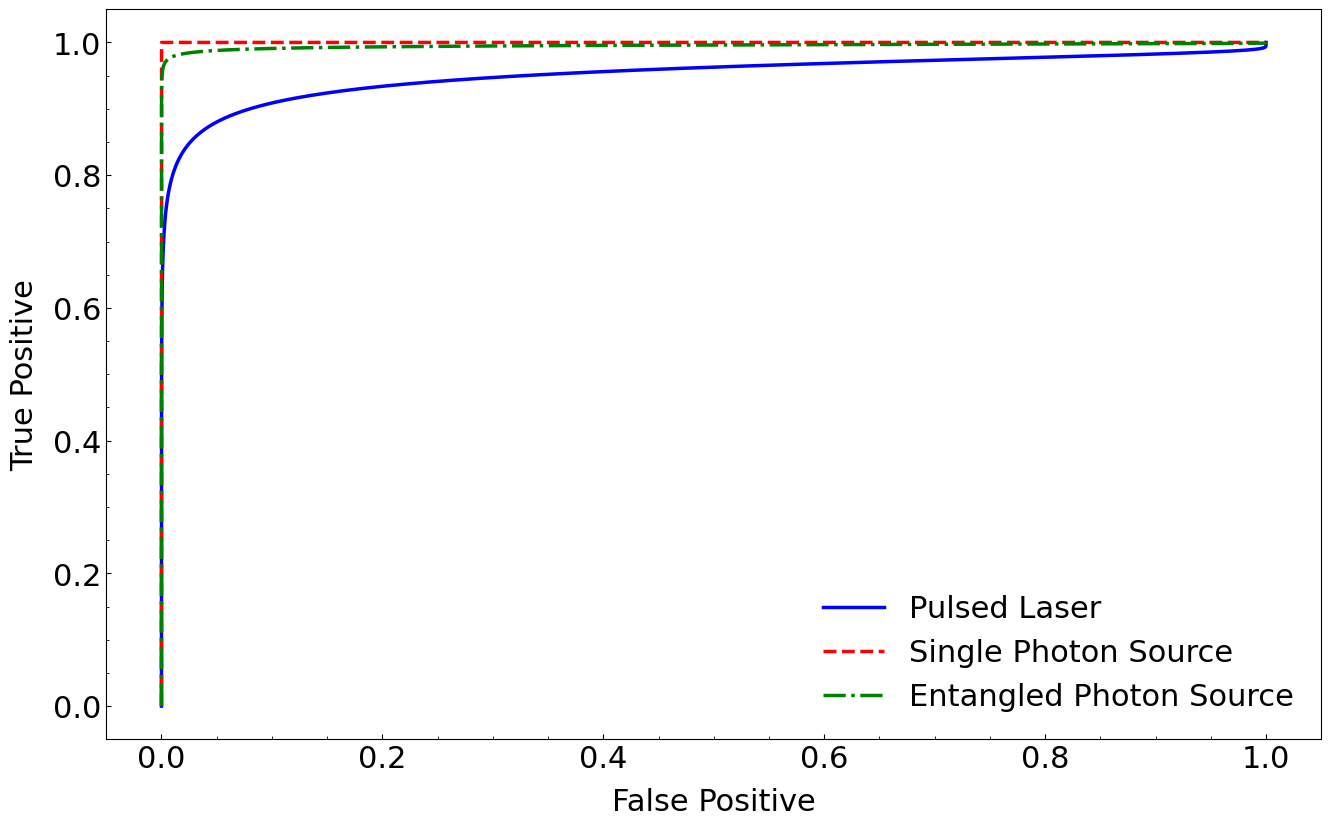

In [11]:
plt.style.use("https://raw.githubusercontent.com/dccote/Enseignement/master/SRC/dccote-errorbars.mplstyle")

fig = plt.figure(figsize=(16.2, 10))

plt.plot(false_positive_laser, true_positive_laser, "-", label="Pulsed Laser", color="blue", linewidth=2.5)
plt.plot(false_positive_sp, true_positive_sp, "--", label="Single Photon Source", color="red", linewidth=2.5)
plt.plot(false_positive_eps, true_positive_eps, "-.", label="Entangled Photon Source", color="green", linewidth=2.5)
plt.xlabel("False Positive", fontsize=22)
plt.ylabel("True Positive", fontsize=22)
plt.legend(frameon=False, fontsize=22)
plt.tick_params(axis='both', which='major', labelsize=22)
plt.tick_params(axis='both', which='minor', labelsize=22)
plt.show()